In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers.models.falcon_mamba.modeling_falcon_mamba import FalconMambaMixer
from transformers.models.falcon_mamba.modeling_falcon_mamba import rms_forward

def load_model(model_name='tiiuae/falcon-mamba-7b', quantize=False):
    """
    Load the model and tokenizer.
    
    Args:
        model_name (str): Name or path of the model to load
        quantize (bool): Whether to apply 4-bit quantization
        
    Returns:
        tuple: (model, tokenizer)
    """
    
    if quantize:
        quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=quantization_config)
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name)
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model.to("cuda:0")
    model.eval()
    return model, tokenizer


# MambaMixer that can be modified

def make_slow_forward_with_hook(orig_slow_forward):
    """
    Returns a new slow_forward method that does exactly what the original
    slow_forward does, except it also saves the intermediate 'scan_output'
    (before multiplying by the gate) in a module attribute, which we can then read later.
    `orig_slow_forward` is the original method we want to wrap.
    """

    # Define an inner function that implements the patched logic.
    def slow_forward_hooked(self, input_states, cache_params=None, cache_position=None, attention_mask=None):
        """
        This function mirrors FalconMambaMixer.slow_forward but includes a step
        to capture the 'scan_output' before gate multiplication.
        """

        # --- replicate the entire original slow_forward logic ---

        # Unpack shapes and data type for convenience
        batch_size, seq_len, _ = input_states.shape
        dtype = input_states.dtype

        # 1. Gated MLP's linear projection: 
        #    We do in_proj -> shape is [batch_size, 2*intermediate_size, seq_len]
        projected_states = self.in_proj(input_states).transpose(1, 2)
        
        # Split into hidden_states and gate. Each has shape [batch_size, intermediate_size, seq_len].
        hidden_states, gate = projected_states.chunk(2, dim=1)

        # If we have an attention mask, apply it to hidden_states.
        if attention_mask is not None:
            # [batch_size, seq_len] -> broadcast along the 'intermediate_size' dimension
            hidden_states = hidden_states * attention_mask.unsqueeze(1)

        # 2. Convolution sequence transformation
        if cache_params is not None:
            # If we have caching, we retrieve the stored SSM state for this layer.
            ssm_state = cache_params.ssm_states[self.layer_idx].clone()
            ssm_state = ssm_state.to(hidden_states.device)

            # cache_position will indicate if we are in a prefill stage or generation stage.
            if cache_position is not None and cache_position.shape[0] == self.conv_kernel_size:
                # This means we are in the very beginning; we pad the hidden_states
                conv_state = torch.nn.functional.pad(
                    hidden_states,
                    (self.conv_kernel_size - hidden_states.shape[-1], 0)
                )
                # Store the padded state in cache
                cache_params.update_conv_state(self.layer_idx, conv_state, cache_position)

                # Perform the convolution, then apply the activation
                hidden_states = self.act(
                    self.conv1d(hidden_states)[..., :seq_len]
                )
            else:
                # If we are in "decoding" step by step, do a specialized update
                conv_state = cache_params.update_conv_state(self.layer_idx, hidden_states, cache_position)
                # Multiply by weight and sum across the sequence dimension
                hidden_states = torch.sum(conv_state * self.conv1d.weight[:, 0, :], dim=-1)
                if self.use_conv_bias:
                    hidden_states += self.conv1d.bias

                # Apply activation (and restore dtype), then unsqueeze for shape consistency
                hidden_states = self.act(hidden_states).to(dtype).unsqueeze(-1)
        else:
            # If we have no caching, just do the usual convolution over the entire sequence
            ssm_state = torch.zeros(
                (batch_size, self.intermediate_size, self.ssm_state_size),
                device=hidden_states.device,
                dtype=dtype
            )
            hidden_states = self.act(
                self.conv1d(hidden_states)[..., :seq_len]
            )

        # Apply attention mask again, if present.
        if attention_mask is not None:
            hidden_states = hidden_states * attention_mask.unsqueeze(1)

        # 3. State Space Model (SSM) sequence transformation
        # 3.a. We compute the input-dependent parameters by projecting hidden_states.
        ssm_parameters = self.x_proj(hidden_states.transpose(1, 2))
        time_step, B, C = torch.split(
            ssm_parameters, [self.time_step_rank, self.ssm_state_size, self.ssm_state_size], dim=-1
        )

        # A small RMS forward pass (normalization) on B, C, and time_step
        B = rms_forward(B, variance_epsilon=self.rms_eps)
        C = rms_forward(C, variance_epsilon=self.rms_eps)
        time_step = rms_forward(time_step, variance_epsilon=self.rms_eps)

        # Discretize the time step: a linear + softplus
        discrete_time_step = self.dt_proj(time_step)
        discrete_time_step = torch.nn.functional.softplus(discrete_time_step).transpose(1, 2)
        # shape -> [batch_size, intermediate_size, seq_len]
        self.delta = discrete_time_step.detach().cpu()

        # Prepare the "A" parameter
        A = -torch.exp(self.A_log.float())  # [intermediate_size, ssm_state_size]

        # Expand A across the sequence dimension to get discrete_A
        discrete_A = torch.exp(A[None, :, None, :] * discrete_time_step[:, :, :, None])
        # shape => [batch_size, intermediate_size, seq_len, ssm_state_size]
        self.A_discrete = discrete_A.detach().cpu()

        # The input-dependent B
        discrete_B = discrete_time_step[:, :, :, None] * B[:, None, :, :].float()
        # shape => [batch_size, intermediate_size, seq_len, ssm_state_size]
        #print('Hidden state size before ssm: ', hidden_states.shape)
        # Multiply by hidden_states to get the final deltaB_u
        deltaB_u = discrete_B * hidden_states[:, :, :, None].float()
        # shape => [batch_size, intermediate_size, seq_len, ssm_state_size]

        # 3.c. Perform the recurrence: we accumulate state across each time step
        scan_outputs = []
        self.collected_ssm_states = [] 
        self.collected_ssm_states.append(ssm_state.detach().cpu())
        for i in range(seq_len):
            # Update the ssm_state for the current step
            ssm_state = discrete_A[:, :, i, :] * ssm_state + deltaB_u[:, :, i, :]
            self.collected_ssm_states.append(ssm_state.detach().cpu())
            # "scan_output" from the SSM part (before gate or D multiplication)
            scan_output_i = torch.matmul(
                ssm_state.to(dtype),  # [batch_size, intermediate_size, ssm_state_size]
                C[:, i, :].unsqueeze(-1)
            )
            # shape => [batch_size, intermediate_size, 1]
            scan_outputs.append(scan_output_i[:, :, 0])  # remove trailing dim

        # Combine the per-step outputs into one tensor => [batch_size, intermediate_size, seq_len]
        scan_output = torch.stack(scan_outputs, dim=-1)
        #print('before u', scan_output.shape)

        # In your code snippet, there's a line:
        #   scan_output = scan_output + (hidden_states * self.D[None, :, None])
        #
        # We'll store this result BEFORE gate multiplication
        scan_output_no_gate = scan_output + (hidden_states * self.D[None, :, None])
        print("success modify")

        # Here is the key: store the pre-gate scan_output in a module attribute
        # so we can retrieve it after forward pass. We detach it from the graph
        # to avoid messing with backprop.
        #self.scan_output_no_gate = scan_output_no_gate.detach().cpu()

        # Next, apply the gate:
        #   scan_output = scan_output_no_gate * self.act(gate)
        scan_output = scan_output_no_gate * self.act(gate)

        #self.scan_output_with_gate = scan_output.detach().cpu()

        # If caching is enabled, update ssm_state in the cache
        if cache_params is not None:
            cache_params.update_ssm_state(self.layer_idx, ssm_state)

        # 4. Final linear projection back to [batch_size, seq_len, hidden_size]
        contextualized_states = self.out_proj(scan_output.transpose(1, 2))

        # Done! Return the final outputs as usual.
        return contextualized_states

    # Return our new slow_forward function
    return slow_forward_hooked

# load modified model
FalconMambaMixer.slow_forward = make_slow_forward_with_hook(FalconMambaMixer.slow_forward)

# 2. Load model
model, tokenizer = load_model(quantize=True)

The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation and https://github.com/Dao-AILab/causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.
Loading checkpoint shards: 100%|██████████| 3/3 [02:22<00:00, 47.63s/it]


In [3]:
input_text = "James loves Paul. Emma loves Chris. James loves"
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

In [34]:
def collect_ssm_state(model, tokenizer, input_text, layer_idx):
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    

    mixer = model.backbone.layers[layer_idx].mixer

    with torch.no_grad():
        _ = model(**inputs)

    # Now collected inside the module!
    return mixer.collected_ssm_states

input_text = "James loves Paul. Emma loves Chris. Sarah loves Mike. John loves Susan. Alex loves Kate. David loves Anna. Mary loves Tom. Mark loves Peter. James loves"
#input_text = "James loves Paul. Emma hates Chris. Sarah sees Mike. John knows Susan. Alex calls Kate. David meets Anna. Mary helps Tom. Mark likes Peter. James loves"
ssm_states = collect_ssm_state(model, tokenizer, input_text, layer_idx=2)

print(f"Number of steps collected: {len(ssm_states)}")
print(f"Each ssm_state shape: {ssm_states[0].shape}")  # [batch_size, intermediate_size, ssm_state_size]


success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
success modify
Number of steps collected: 35
Each ssm_s

In [35]:
def process_collected_ssm_states(collected_ssm_states):
    """
    Process collected ssm_states: take only the first intermediate_size at each step.
    
    Args:
        collected_ssm_states (list of Tensor): each tensor shape [batch_size, intermediate_size, ssm_state_size]
        
    Returns:
        Tensor: [seq_len, ssm_state_size]
    """
    selected = []
    for ssm_state in collected_ssm_states:
        first_intermediate = ssm_state[0, 0]  # batch=0, intermediate=0
        selected.append(first_intermediate)   # shape [ssm_state_size]
    
    # Stack over timesteps
    result = torch.stack(selected, dim=0)  # shape [seq_len, ssm_state_size]
    return result

processed_ssm = process_collected_ssm_states(ssm_states)

In [36]:
processed_ssm.shape

torch.Size([35, 16])

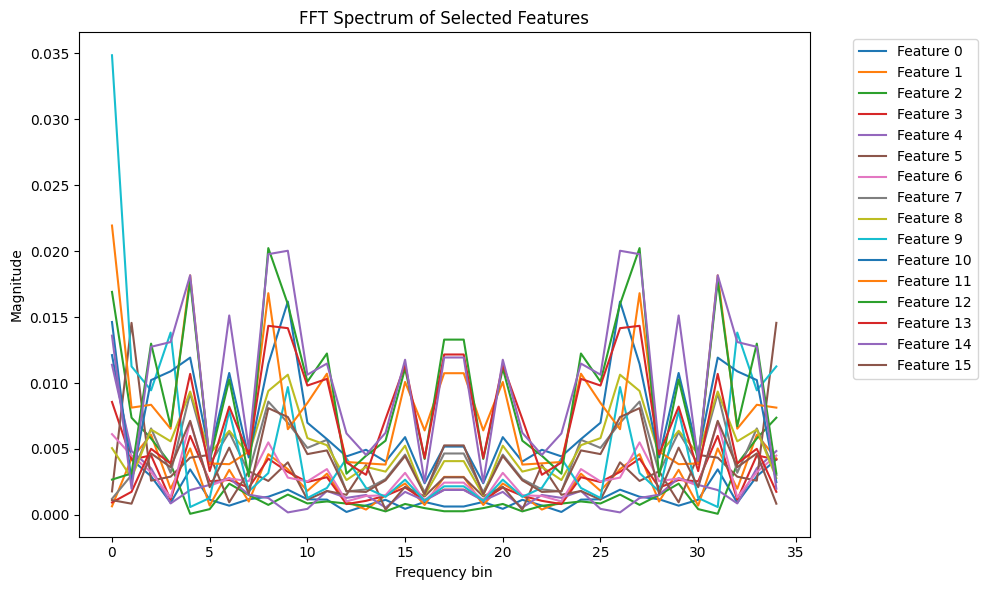

In [33]:
import torch
import matplotlib.pyplot as plt

fft_result = torch.fft.fft(processed_ssm, dim=0)

# Get magnitude
fft_magnitude = torch.abs(fft_result)

# Plot for few features
features_to_plot = [i for i in range(16)]
import matplotlib.pyplot as plt

# Suppose your FFT magnitude already computed
# fft_magnitude = ...

plt.figure(figsize=(10, 6))
for feature_idx in range(16):
    plt.plot(fft_magnitude[:, feature_idx].cpu().numpy(), label=f"Feature {feature_idx}")

plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.title("FFT Spectrum of Selected Features")

# 🔥 Move the legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # 🔥 Also add tight_layout to avoid cutting off labels
plt.show()


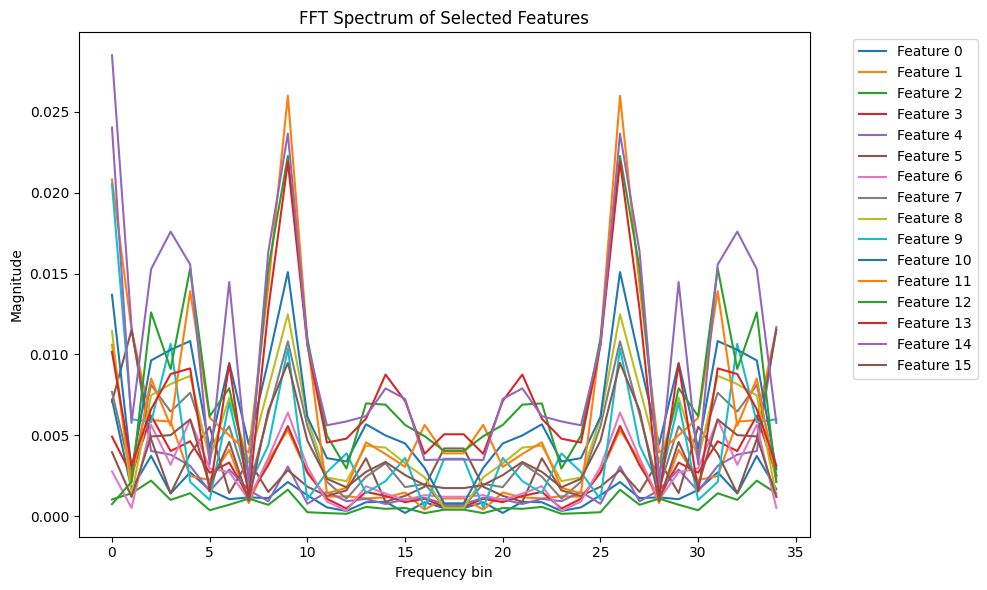

In [37]:
import torch
import matplotlib.pyplot as plt

fft_result = torch.fft.fft(processed_ssm, dim=0)

# Get magnitude
fft_magnitude = torch.abs(fft_result)

# Plot for few features
features_to_plot = [i for i in range(16)]
import matplotlib.pyplot as plt

# Suppose your FFT magnitude already computed
# fft_magnitude = ...

plt.figure(figsize=(10, 6))
for feature_idx in range(16):
    plt.plot(fft_magnitude[:, feature_idx].cpu().numpy(), label=f"Feature {feature_idx}")

plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.title("FFT Spectrum of Selected Features")

# 🔥 Move the legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # 🔥 Also add tight_layout to avoid cutting off labels
plt.show()